In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import pprint

In [2]:
# open csv file
df = pd.read_csv("../data/cleaned/town_level_merged_for_eda.csv")

# open geojson file
gdf = gpd.read_file("../data/cleaned/census.geojson")

#### Clean data and functions for building index and model evaluation

In [3]:
# clean up missing values - fill funding and claims NaNs with 0,
# drop towns with zero population, and display remaining NaNs in ACS columns

# columns to check for NaNs
cols_to_check = [
    # "pct_river_corridor",
    # "pct_high_risk_NFHL",
    "median_income",
    "percent_elderly",
    "median_year_house_built",
    "pct_no_vehicle",
    "pct_renter_occupied",
    "pct_bachelors_or_higher",
    "pct_below_poverty",
    "percent_with_disability",
    "pct_mobile_home",
    # "funding_per_capita",
    # "log_funding_per_capita",
    # "funding_per_occupied_unit",
    # "log_funding_per_occupied_unit",
    # "claims_paid_per_capita",
    # "current_insurance_penetration",
]
# # print statement commented out, but left in case of testing (as with above columns)
# print("Missing values in key columns:")
# for col in cols_to_check:
#     missing = df[col].isna().sum()
#     print(f"{col}: {missing} missing values")

# fill funding and claims NaNs with 0
cols_to_fill = [
    "funding_per_capita",
    "log_funding_per_capita",
    "funding_per_occupied_unit",
    "log_funding_per_occupied_unit",
    "claims_paid_per_capita",
    "current_insurance_penetration",
]
df[cols_to_fill] = df[cols_to_fill].fillna(0)

# drop towns with zero population
print(f"\nTowns before filtering for zero population: {len(df)}")
df = df[df["total_population"] > 0]
print(f"Towns after filtering for zero population: {len(df)}\n")

# display remaining NaNs in ACS columns
print("Missing values in key columns:")
for col in cols_to_check:
    missing = df[col].isna().sum()
    print(f"{col}: {missing} missing values")


Towns before filtering for zero population: 256
Towns after filtering for zero population: 250

Missing values in key columns:
median_income: 3 missing values
percent_elderly: 0 missing values
median_year_house_built: 6 missing values
pct_no_vehicle: 0 missing values
pct_renter_occupied: 0 missing values
pct_bachelors_or_higher: 0 missing values
pct_below_poverty: 0 missing values
percent_with_disability: 0 missing values
pct_mobile_home: 0 missing values


In [4]:
def preprocess(df, cols_to_scale, log_transform=None):
    df = df.copy()

    # optional log transformation
    if log_transform:
        for col in log_transform:
            # if col start with "log_", skip log transformation
            # safeguard against accidentally double-log-transforming variables
            if col.startswith("log_"):
                continue
            df[col] = np.log1p(df[col])

    # z-score variables
    scaler = StandardScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

    return df


def build_index(df, risk_vars, vuln_vars, funding_var, mode="add"):
    df = df.copy()

    # calculate risk and vulnerability indices as the mean of their respective (z-scored) variables
    if risk_vars:
        df["risk_index"] = df[risk_vars].mean(axis=1)
    else:
        df["risk_index"] = 0
    if vuln_vars:
        df["vuln_index"] = df[vuln_vars].mean(axis=1)
    else:
        df["vuln_index"] = 0

    # calculate need index as the sum of risk and vulnerability indices
    # (could also experiment with weighted sum or other combinations)
    df["need_index"] = df["risk_index"] + df["vuln_index"]

    # calculate the gap index as the difference between funding and need
    # positive gap means overfunded relative to need, negative gap means underfunded
    df["gap_index"] = df[funding_var] - df["need_index"]

    return df


def run_ols(df, X_vars, y_var):
    # add constant for intercept
    X = sm.add_constant(df[X_vars])
    y = df[y_var]

    # fit OLS model
    model = sm.OLS(y, X).fit()

    # save predictions and residuals back to dataframe
    # positive residual means overfunded relative to model prediction, negative residual means underfunded
    df = df.copy()
    df["predicted"] = model.predict(X)
    df["residual"] = df[y_var] - df["predicted"]

    # add ranking columns
    df["gap_rank"] = df["gap_index"].rank()
    df["resid_rank"] = df["residual"].rank()
    df["rank_diff"] = df["gap_rank"] - df["resid_rank"]
    # df["abs_rank_diff"] = df["rank_diff"].abs()

    return df, model

In [5]:
def evaluate(df, model):
    # calculate correlation between gap index and residuals
    corr = df["gap_index"].corr(df["residual"])
    # calculate rank-based correlation between gap index and residuals
    # (i.e., do areas with higher gap index also tend to have higher residuals, even if not perfectly linear?)
    rank_corr, _ = spearmanr(df["gap_index"], df["residual"])

    # compile evaluation summary
    summary = {
        "r2": model.rsquared,
        "adj_r2": model.rsquared_adj,
        "n_vars": len(model.params) - 1,
        "n_obs": int(model.nobs),
        "gap_resid_corr": corr,
        "gap_resid_spearman_corr": rank_corr,
        "coef_signs": model.params.to_dict(),
    }

    # add direction of coefficients to summary
    summary["coef_directions"] = {
        k: "pos" if v > 0 else "neg" for k, v in model.params.items()
    }

    return summary


def plot_basic(df, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # gap_index vs residual
    axes[0].scatter(df["gap_index"], df["residual"])
    axes[0].set_xlabel("Index Gap")
    axes[0].set_ylabel("OLS Residual")
    axes[0].set_title(title)
    axes[0].axhline(0, color="gray", linestyle="--")
    axes[0].axvline(0, color="gray", linestyle="--")

    # predicted vs residual
    axes[1].scatter(df["predicted"], df["residual"])
    axes[1].set_xlabel("Predicted Values")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title("Predicted vs Residuals")
    axes[1].axhline(0, color="gray", linestyle="--")
    axes[1].axvline(0, color="gray", linestyle="--")

    plt.tight_layout()
    plt.show()


def plot_choropleths(
    df, gdf, value_cols=["gap_index", "residual"], geoid_col="GEOID", title_prefix=""
):
    # ensure types are correct for merging
    df[geoid_col] = df[geoid_col].astype(str)
    gdf[geoid_col] = gdf[geoid_col].astype(str)

    # Merge result df with geodataframe on GEOID
    plot_gdf = gdf.merge(df[[geoid_col] + value_cols], on=geoid_col, how="left")

    fig, axes = plt.subplots(1, len(value_cols), figsize=(7 * len(value_cols), 8))
    if len(value_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, value_cols):
        plot_gdf.plot(
            column=col,
            cmap="coolwarm",
            # set vmin and vmax to be symmetric around zero, to ensure consistent coloring of over- vs underfunded areas
            vmin=-abs(plot_gdf[col]).max(),
            vmax=abs(plot_gdf[col]).max(),
            linewidth=0.2,
            edgecolor="gray",
            legend=True,
            ax=ax,
            missing_kwds={"color": "lightgrey", "label": "Missing"},
        )
        ax.set_title(f"{title_prefix}{col}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [6]:
def get_extremes(df, col, n=10):
    return {
        "lowest": df.nsmallest(n, col)[["town_name", col]],
        "highest": df.nlargest(n, col)[["town_name", col]],
        "rank_highest": df[["town_name", "rank_diff"]].nlargest(n, "rank_diff"),
        "rank_lowest": df[["town_name", "rank_diff"]].nsmallest(n, "rank_diff"),
        # "abs_rank_mismatch": df[["town_name", "abs_rank_diff"]].nlargest(n, "abs_rank_diff"),
    }


def get_mismatch(df, n=10):
    df = df.copy()
    df["abs_rank_diff"] = df["rank_diff"].abs()
    return df.nlargest(n, "abs_rank_diff")[
        ["town_name", "gap_index", "residual", "rank_diff", "abs_rank_diff"]
    ]

In [7]:
def run_model_suite(df, gdf, model_specs):
    all_results = {}
    summary_rows = []

    for name, spec in model_specs.items():
        print(f"\n=== RUNNING: {name} ===")

        # extract spec components
        risk_vars = spec.get("risk", [])
        vuln_vars = spec.get("vuln", [])
        # spec components with defaults
        funding_var = spec.get("funding_var", "log_funding_per_capita")
        log_transform = spec.get("log_transform", None)
        index_mode = spec.get("index_mode", "add")
        do_plots = spec.get("do_plots", True)

        # define X variables and columns to scale based on spec
        X_vars = risk_vars + vuln_vars
        cols_to_scale = risk_vars + vuln_vars + [funding_var]

        # drop any rows with missing values in the relevant columns for this model spec
        relevant_cols = set(X_vars + [funding_var])
        df_valid = df.dropna(subset=relevant_cols)

        # preprocess
        df_proc = preprocess(df_valid, cols_to_scale, log_transform)

        # index
        df_idx = build_index(
            df_proc, risk_vars, vuln_vars, funding_var, mode=index_mode
        )

        # model
        df_model, model = run_ols(df_idx, X_vars, funding_var)

        # evaluate
        metrics = evaluate(df_model, model)
        metrics["model"] = name

        summary_rows.append(metrics)

        # store full outputs
        all_results[name] = {"df": df_model, "model": model, "metrics": metrics}

        # plots
        if do_plots:
            plot_basic(df_model, title=name)
            plot_choropleths(df_model, gdf, title_prefix=name + " - ")

        # print mismatch results
        display(get_mismatch(df_model, n=20))

        # print(metrics)

    summary_df = pd.DataFrame(summary_rows).sort_values(by="r2", ascending=False)

    print("\n=== SUMMARY ===")
    display(summary_df)

    return all_results, summary_df

# Define inputs and evalute index / models

In [8]:
model_specs = {
    "baseline_exposure": {"risk": ["pct_river_corridor"]},
    "baseline_vulnerability": {
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
        "log_transform": ["pct_below_poverty"],
    },
    "core_model": {
        "risk": ["pct_river_corridor"],
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
        "log_transform": ["pct_below_poverty"],
    },
    "expanded_model": {
        "risk": ["pct_river_corridor"],
        "vuln": [
            "pct_below_poverty",
            "percent_elderly",
            "pct_no_vehicle",
            "pct_renter_occupied",
            "pct_mobile_home",
        ],
        "log_transform": ["pct_below_poverty"],
    },
    "nfhl_model": {
        "risk": ["pct_high_risk_NFHL"],
        "vuln": ["pct_below_poverty", "percent_elderly"],
        "log_transform": ["pct_below_poverty"],
    },
    "claims_only": {"risk": ["claims_paid_per_capita"]},
    "combined": {
        "risk": ["pct_river_corridor"],
        "vuln": ["pct_below_poverty", "percent_elderly"],
        "log_transform": ["pct_below_poverty"],
    },
}


=== RUNNING: baseline_exposure_log_funding_per_capita ===


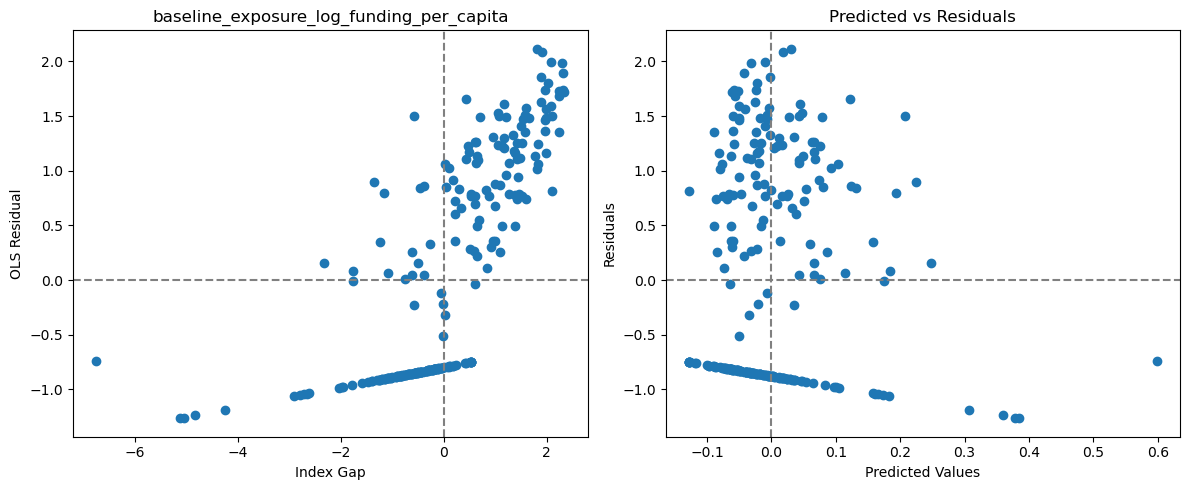

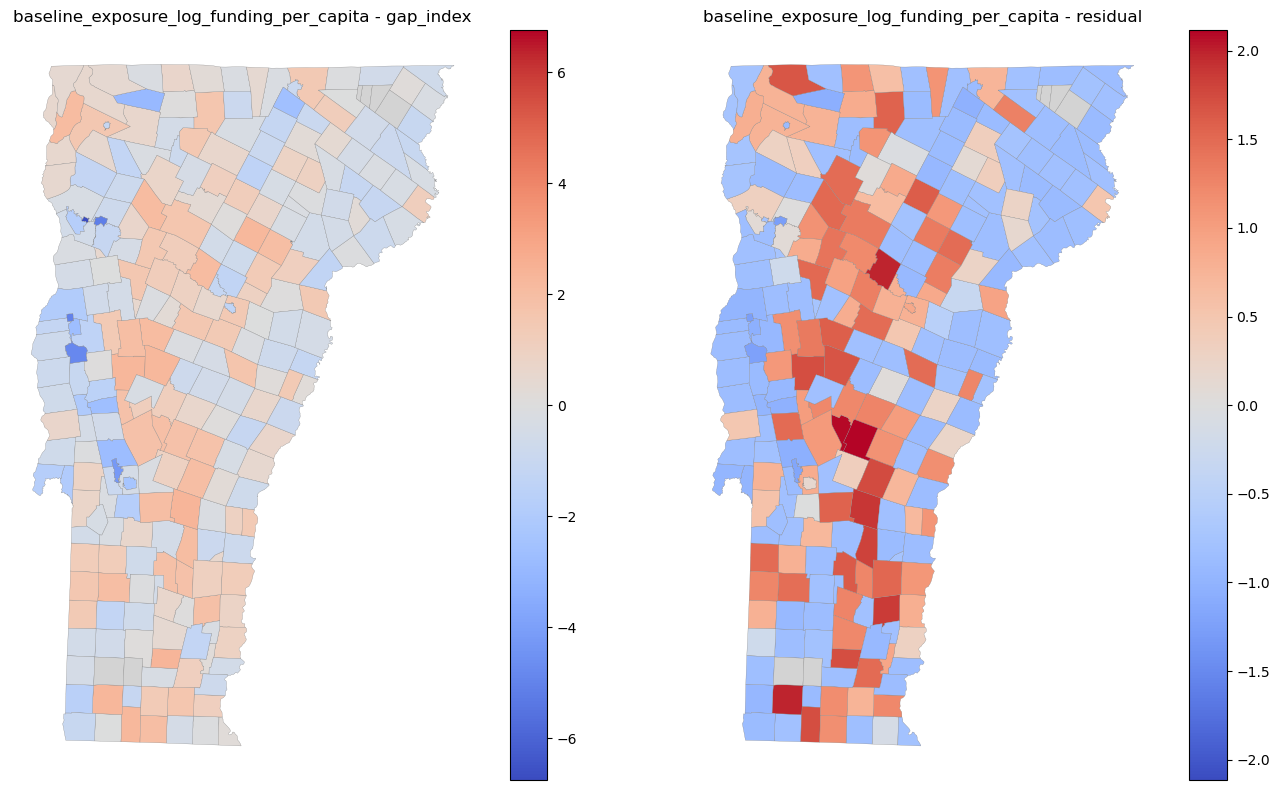

,town_name,gap_index,residual,rank_diff,abs_rank_diff
12,Barre city,-1.360176,0.898842,-164.0,164.0
25,Brandon town,-0.583816,1.499075,-155.0,155.0
132,Montpelier city,-1.154390,0.792410,-147.0,147.0
174,Rutland city,-2.327448,0.154084,-134.0,134.0
250,Winooski city,-6.750964,-0.743974,-130.0,130.0
71,Fairfax town,-1.241575,0.346045,-128.0,128.0
37,Burlington city,-1.766795,0.085105,-127.0,127.0
49,Clarendon town,-1.762646,-0.009525,-121.0,121.0
245,Williston town,-1.076706,0.069179,-105.0,105.0
175,Rutland town,-0.468579,0.844963,-93.0,93.0



=== RUNNING: baseline_vulnerability_log_funding_per_capita ===


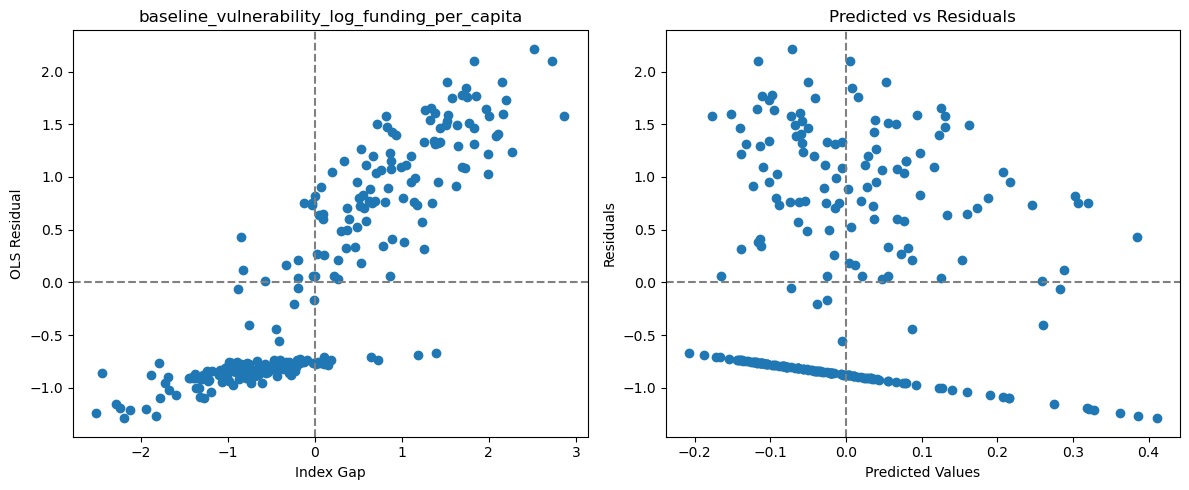

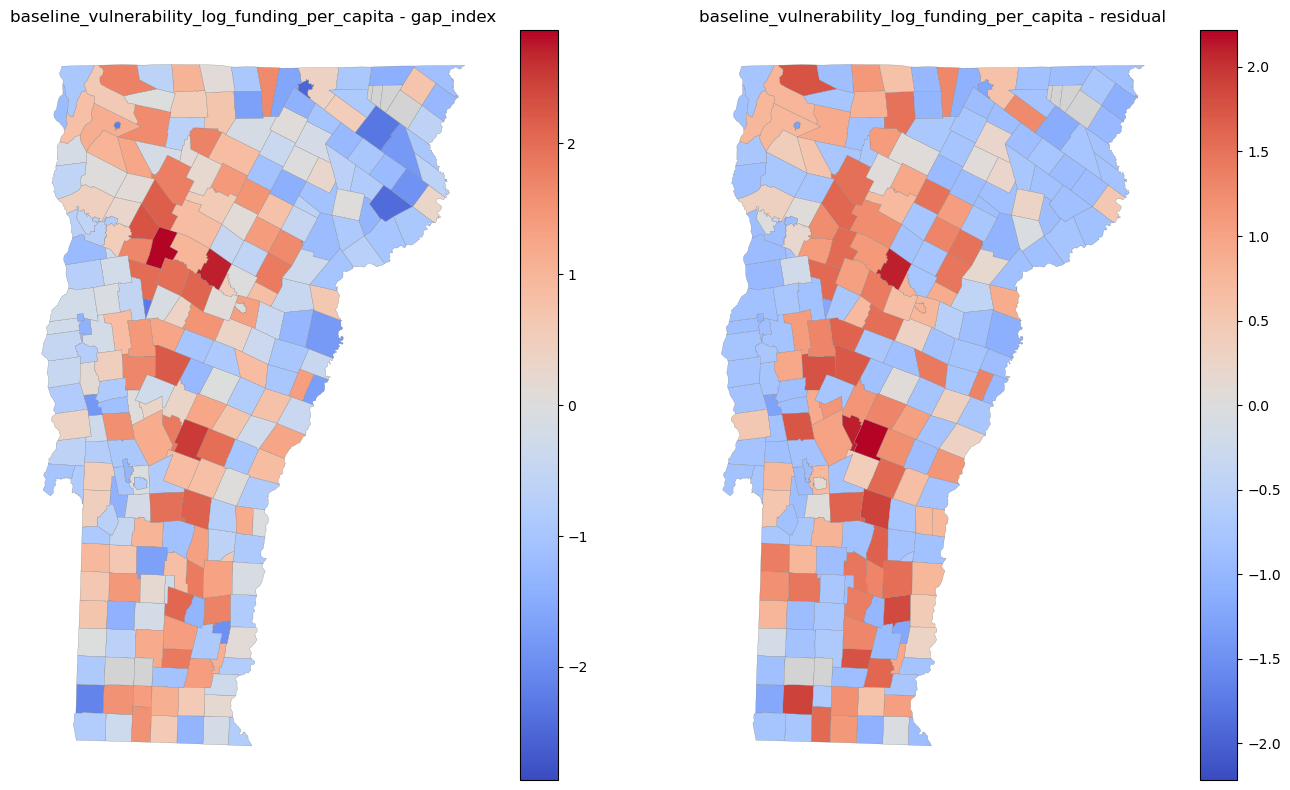

,town_name,gap_index,residual,rank_diff,abs_rank_diff
75,Ferdinand town,-1.791987,-0.766117,-96.0,96.0
170,Rockingham town,-0.845003,0.434629,-91.0,91.0
179,Searsburg town,1.387220,-0.671219,85.0,85.0
194,St. Johnsbury town,-0.882152,-0.063063,-76.0,76.0
201,Stratton town,1.182849,-0.690562,75.0,75.0
21,Bloomfield town,-0.605449,-0.954662,74.0,74.0
174,Rutland city,-0.830600,0.113036,-74.0,74.0
150,Panton town,-0.272813,-0.879734,73.0,73.0
23,Bradford town,-0.440341,-0.889904,67.0,67.0
171,Roxbury town,-0.989846,-0.757722,-67.0,67.0



=== RUNNING: core_model_log_funding_per_capita ===


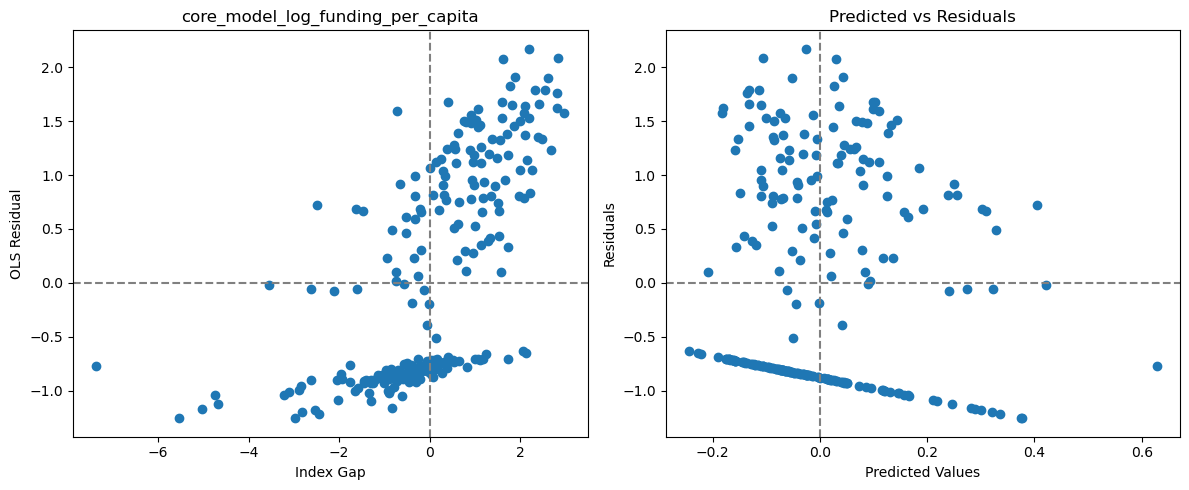

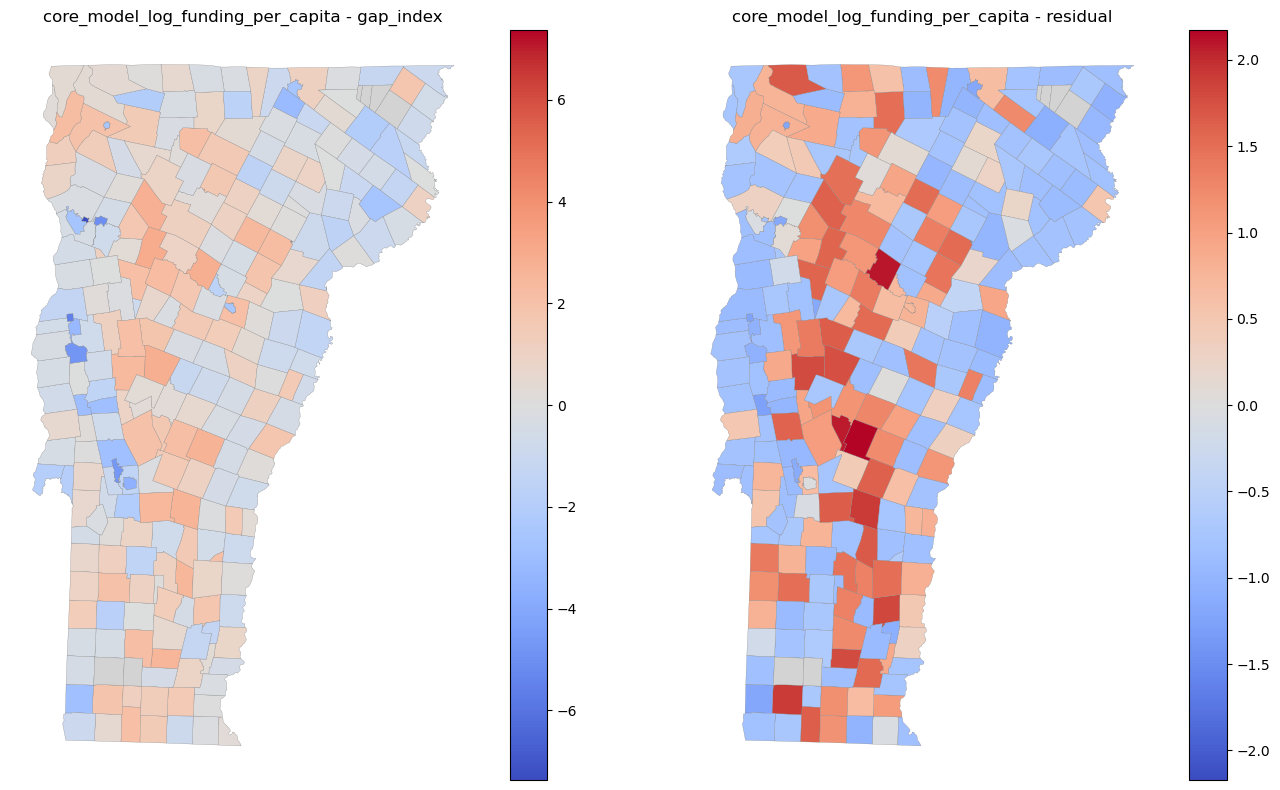

,town_name,gap_index,residual,rank_diff,abs_rank_diff
25,Brandon town,-0.711861,1.596641,-172.0,172.0
12,Barre city,-2.479576,0.719346,-156.0,156.0
132,Montpelier city,-1.630238,0.684748,-144.0,144.0
175,Rutland town,-1.477756,0.666792,-138.0,138.0
174,Rutland city,-3.559190,-0.020434,-134.0,134.0
37,Burlington city,-2.613073,-0.054058,-125.0,125.0
126,Middlebury town,-0.654805,0.915057,-122.0,122.0
49,Clarendon town,-2.123784,-0.075523,-118.0,118.0
194,St. Johnsbury town,-1.603897,-0.054521,-111.0,111.0
170,Rockingham town,-0.841093,0.491597,-105.0,105.0



=== RUNNING: expanded_model_log_funding_per_capita ===


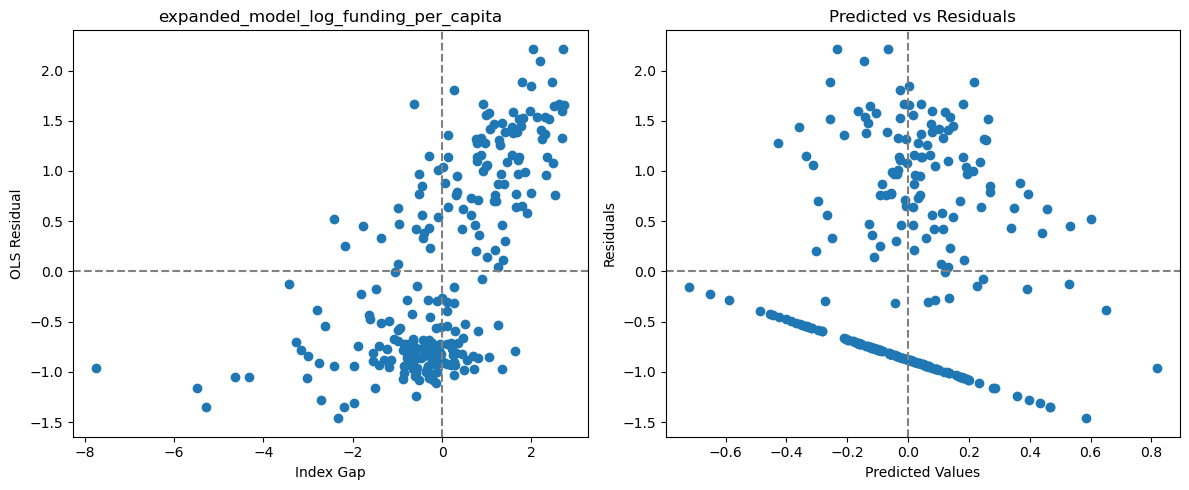

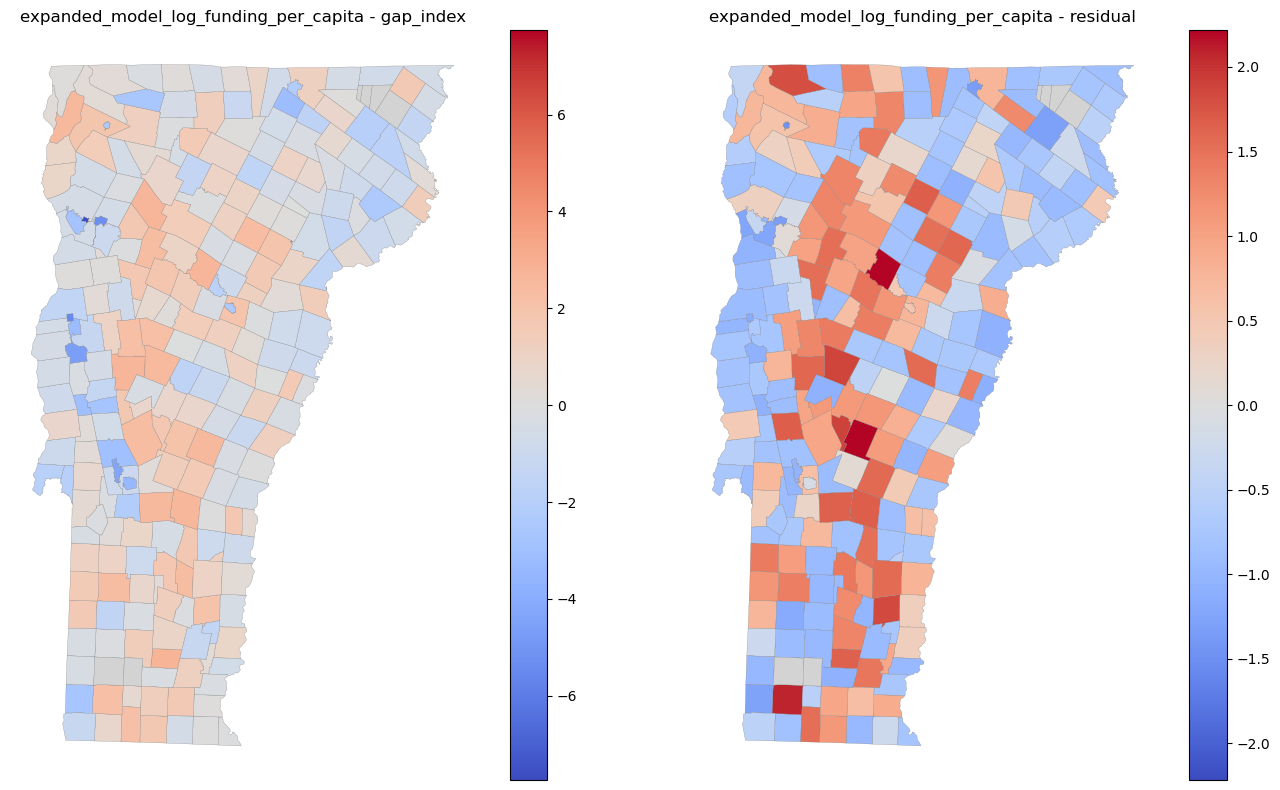

,town_name,gap_index,residual,rank_diff,abs_rank_diff
201,Stratton town,1.343927,-0.968455,175.0,175.0
25,Brandon town,-0.638623,1.662394,-173.0,173.0
12,Barre city,-2.411741,0.523555,-147.0,147.0
153,Peru town,0.703865,-0.971369,142.0,142.0
6,Averill town,1.641214,-0.790221,138.0,138.0
238,Westmore town,0.495277,-0.980998,138.0,138.0
132,Montpelier city,-1.762062,0.453560,-135.0,135.0
174,Rutland city,-3.425309,-0.129276,-134.0,134.0
49,Clarendon town,-2.171561,0.256207,-131.0,131.0
35,Buels gore,0.268253,-1.035672,130.0,130.0



=== RUNNING: nfhl_model_log_funding_per_capita ===


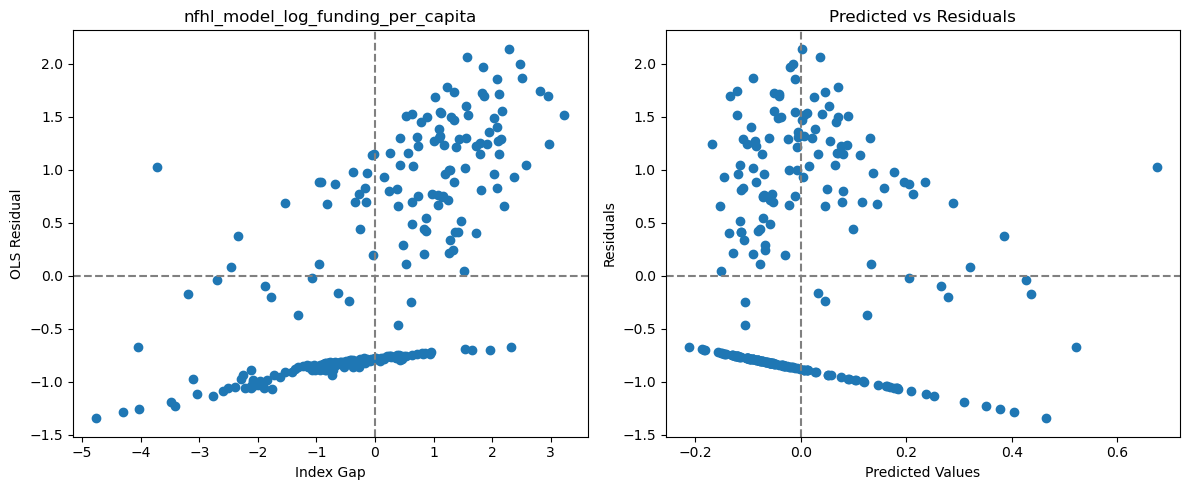

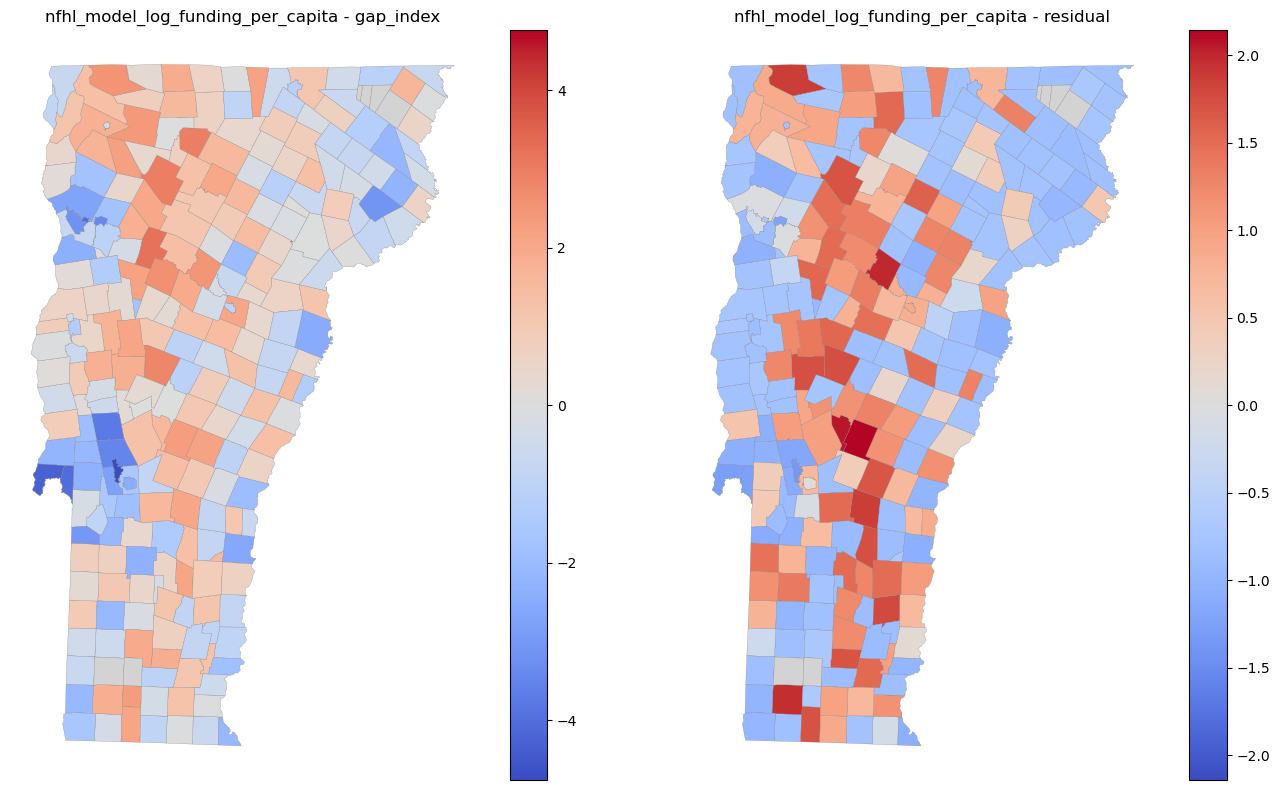

,town_name,gap_index,residual,rank_diff,abs_rank_diff
25,Brandon town,-3.727130,1.031856,-190.0,190.0
42,Castleton town,-2.339033,0.374498,-135.0,135.0
243,Whitingham town,-0.960381,0.888704,-134.0,134.0
37,Burlington city,-3.191838,-0.166899,-129.0,129.0
175,Rutland town,-1.531765,0.688124,-129.0,129.0
12,Barre city,-0.929383,0.888236,-128.0,128.0
50,Colchester town,-2.695533,-0.040264,-128.0,128.0
174,Rutland city,-2.459139,0.080040,-128.0,128.0
250,Winooski city,-4.051770,-0.668456,-127.0,127.0
179,Searsburg town,2.327918,-0.666741,111.0,111.0



=== RUNNING: claims_only_log_funding_per_capita ===


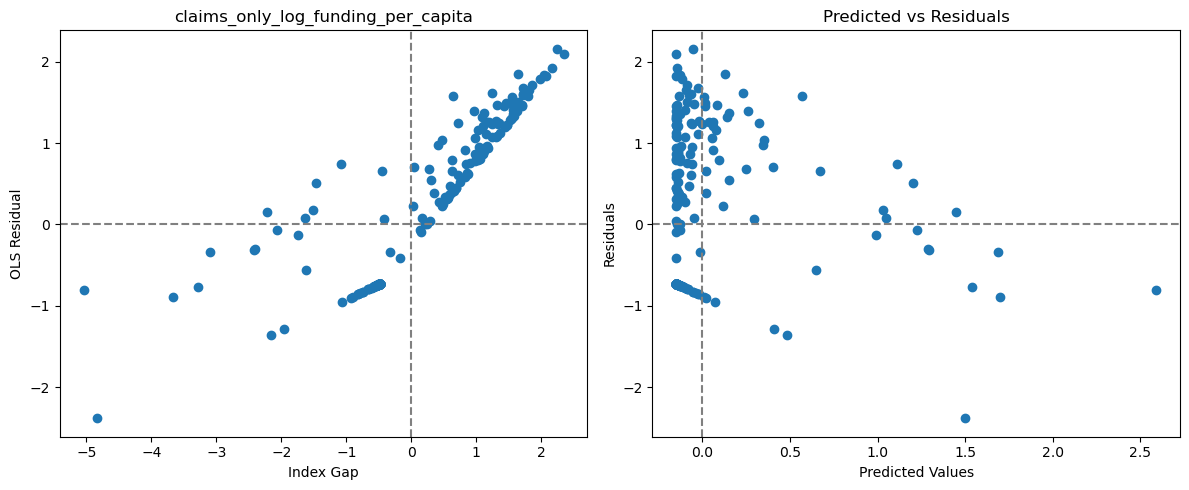

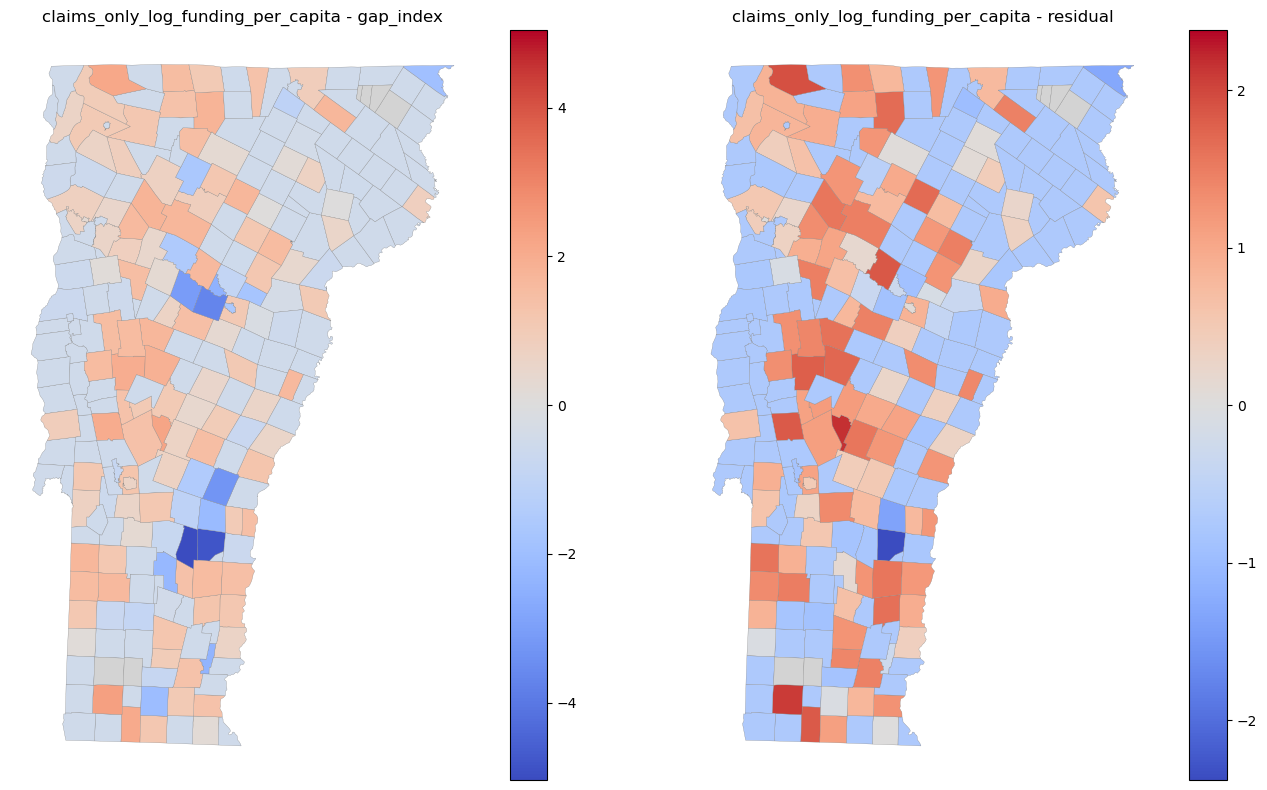

,town_name,gap_index,residual,rank_diff,abs_rank_diff
157,Plymouth town,-1.083432,0.736912,-162.0,162.0
27,Bridgewater town,-1.459846,0.507888,-152.0,152.0
239,Weston town,-2.220434,0.150740,-142.0,142.0
226,Waterbury town,-1.509598,0.178015,-136.0,136.0
12,Barre city,-1.635877,0.076316,-135.0,135.0
246,Wilmington town,-2.071094,-0.066340,-133.0,133.0
32,Brookline town,-2.400691,-0.296199,-132.0,132.0
132,Montpelier city,-2.422143,-0.307437,-132.0,132.0
133,Moretown town,-3.096261,-0.339602,-132.0,132.0
156,Plainfield town,-1.746662,-0.123006,-128.0,128.0



=== RUNNING: combined_log_funding_per_capita ===


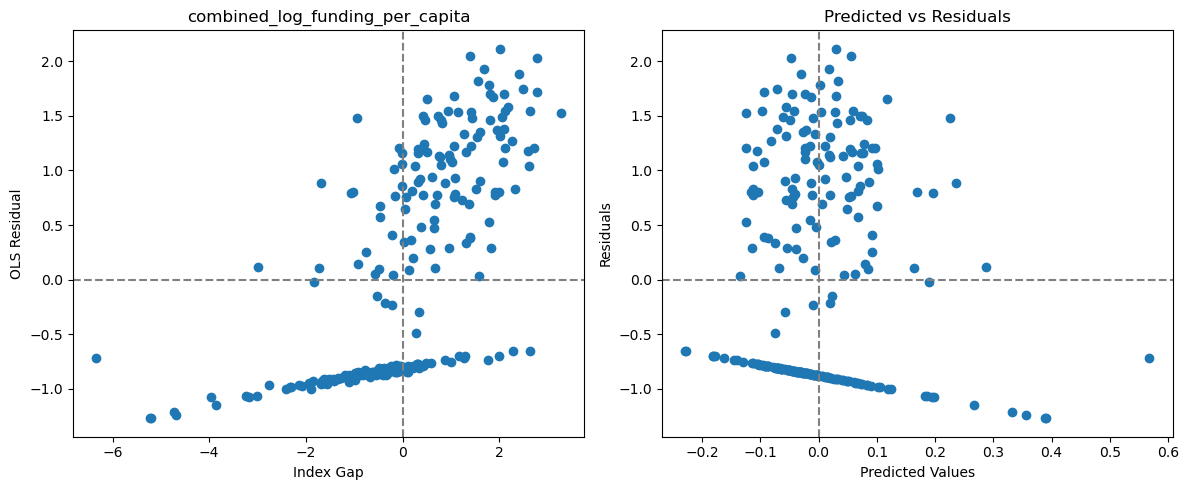

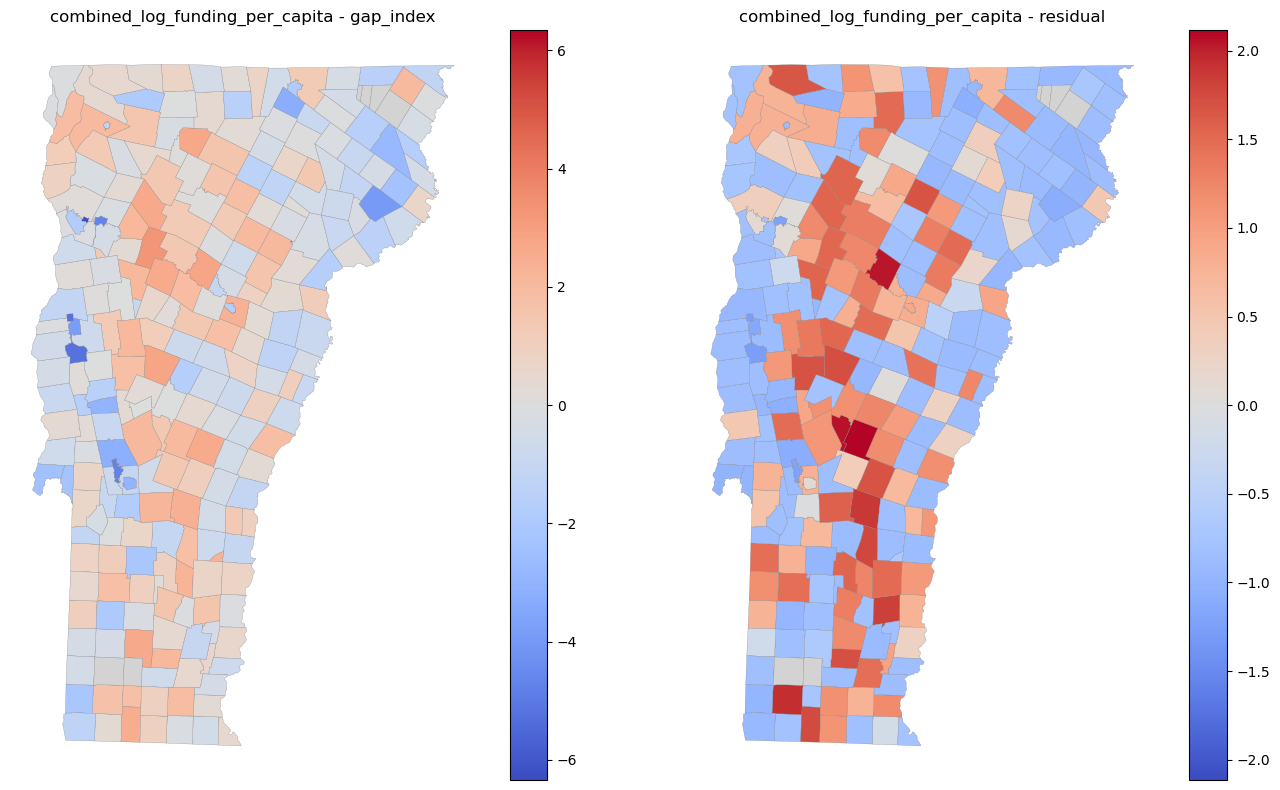

,town_name,gap_index,residual,rank_diff,abs_rank_diff
25,Brandon town,-0.935619,1.481506,-174.0,174.0
12,Barre city,-1.680303,0.888156,-160.0,160.0
174,Rutland city,-2.995859,0.113107,-134.0,134.0
175,Rutland town,-1.023353,0.806361,-132.0,132.0
132,Montpelier city,-1.064102,0.790620,-130.0,130.0
250,Winooski city,-6.338223,-0.713709,-125.0,125.0
37,Burlington city,-1.738085,0.106408,-122.0,122.0
49,Clarendon town,-1.824162,-0.024063,-116.0,116.0
201,Stratton town,2.628340,-0.650639,115.0,115.0
9,Baltimore town,2.287498,-0.649820,108.0,108.0



=== RUNNING: baseline_exposure_log_funding_per_occupied_unit ===


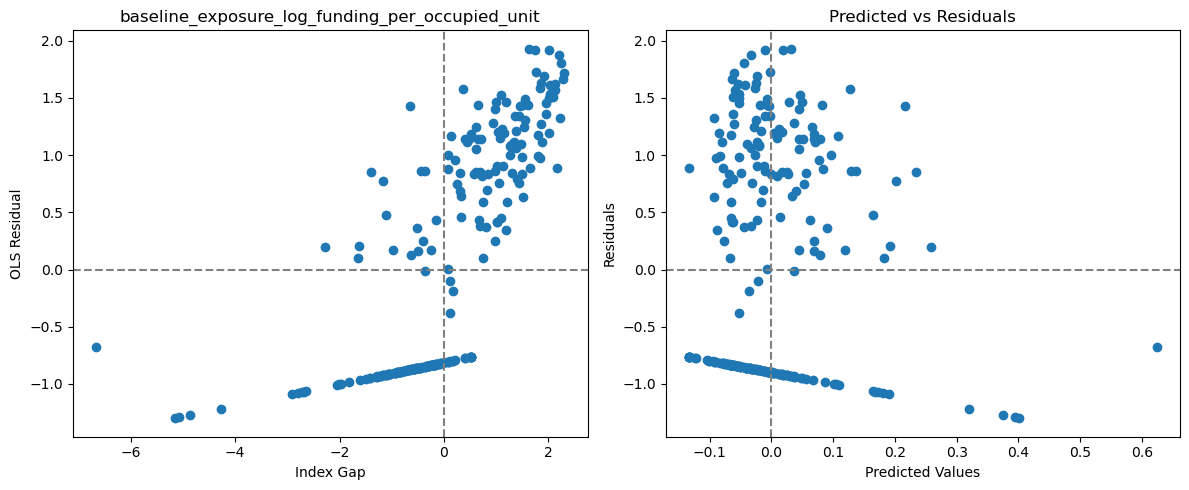

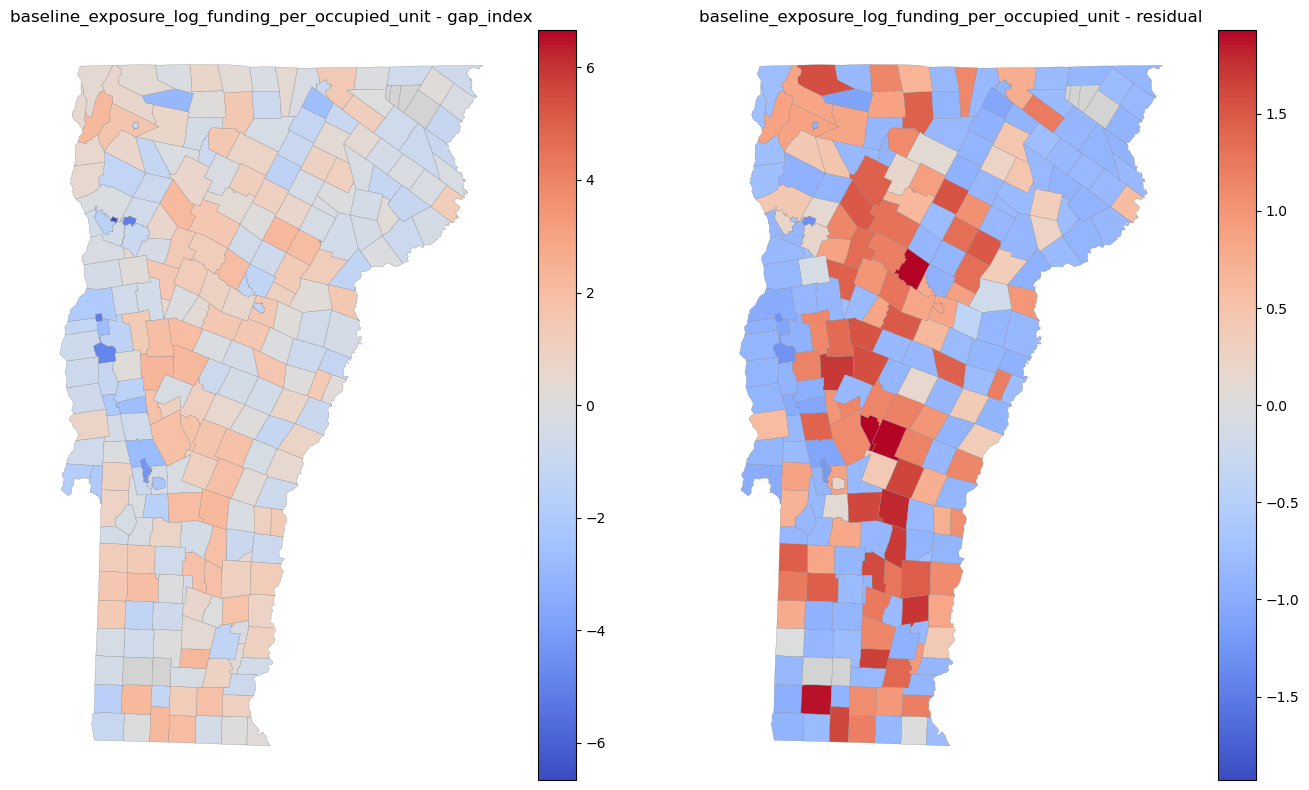

,town_name,gap_index,residual,rank_diff,abs_rank_diff
25,Brandon town,-0.644325,1.429673,-155.0,155.0
12,Barre city,-1.400337,0.849036,-153.0,153.0
132,Montpelier city,-1.161862,0.776625,-136.0,136.0
174,Rutland city,-2.269853,0.201085,-132.0,132.0
250,Winooski city,-6.657560,-0.676216,-130.0,130.0
37,Burlington city,-1.634942,0.209051,-127.0,127.0
49,Clarendon town,-1.641182,0.104454,-122.0,122.0
71,Fairfax town,-1.101351,0.479491,-122.0,122.0
245,Williston town,-0.970452,0.170541,-99.0,99.0
175,Rutland town,-0.447310,0.860624,-86.0,86.0



=== RUNNING: baseline_vulnerability_log_funding_per_occupied_unit ===


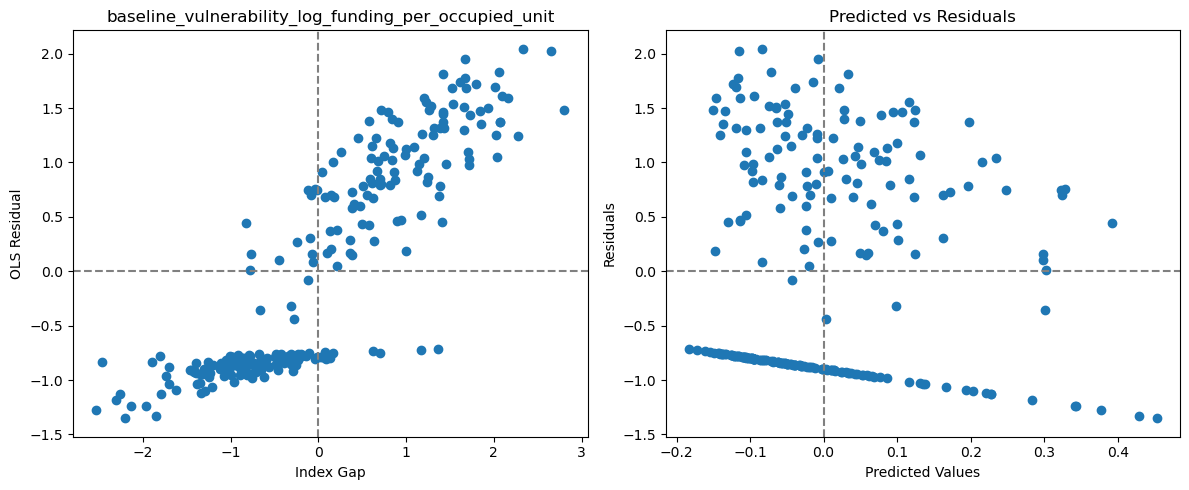

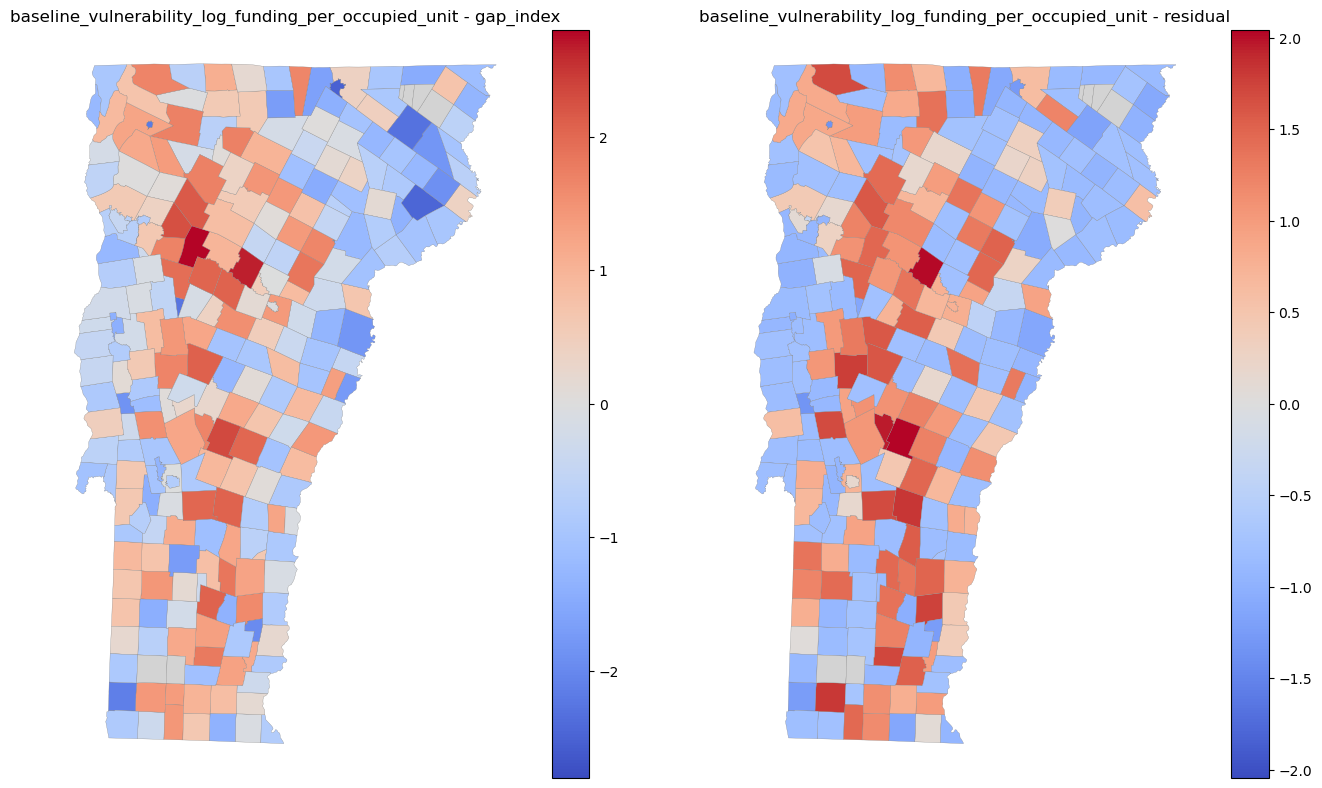

,town_name,gap_index,residual,rank_diff,abs_rank_diff
75,Ferdinand town,-1.811421,-0.781802,-99.0,99.0
150,Panton town,-0.292247,-0.914298,82.0,82.0
170,Rockingham town,-0.826164,0.446295,-82.0,82.0
179,Searsburg town,1.367787,-0.715273,82.0,82.0
21,Bloomfield town,-0.624883,-0.974785,75.0,75.0
216,Victory town,-2.470323,-0.829991,-74.0,74.0
201,Stratton town,1.163416,-0.725700,71.0,71.0
23,Bradford town,-0.459775,-0.911867,66.0,66.0
84,Granby town,-1.899769,-0.836817,-66.0,66.0
45,Charlotte town,-0.754536,-0.984319,63.0,63.0



=== RUNNING: core_model_log_funding_per_occupied_unit ===


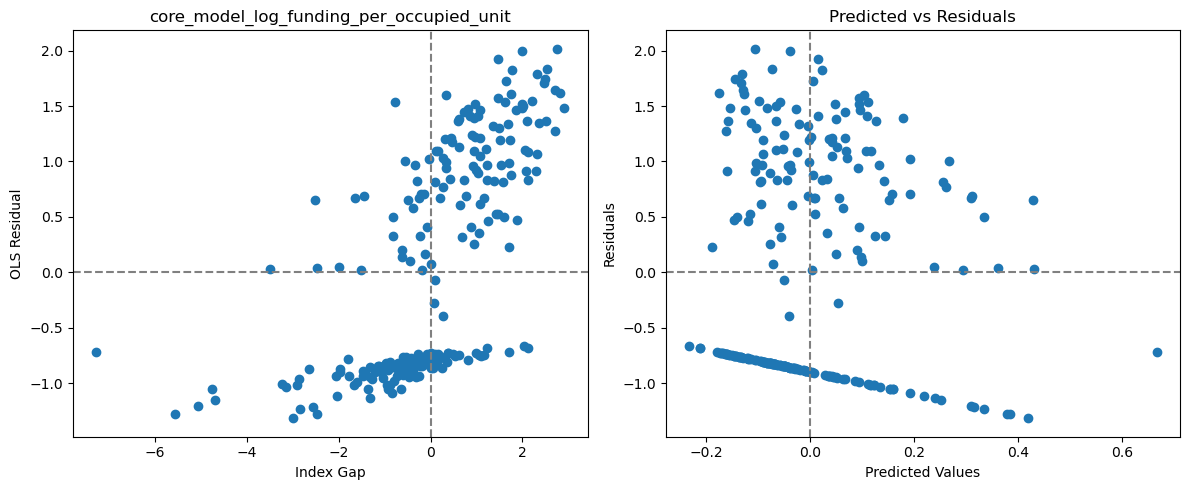

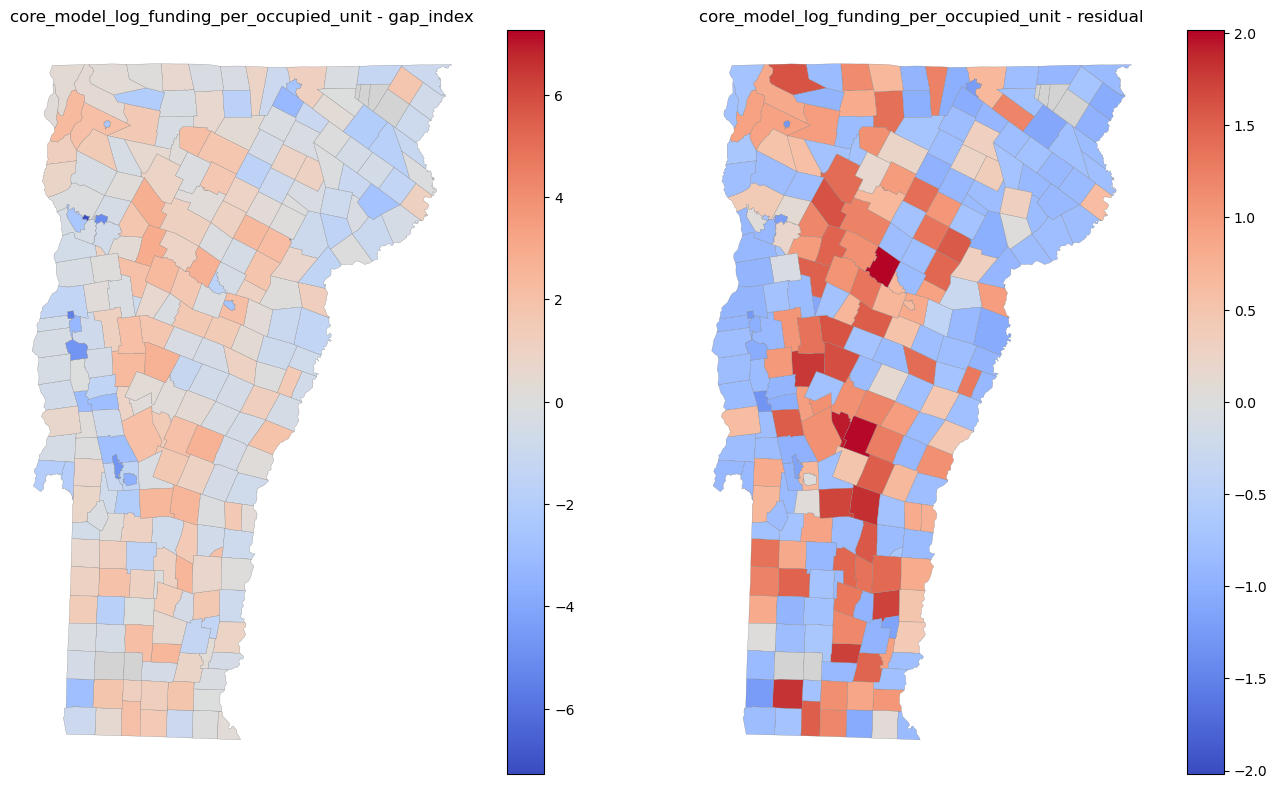

,town_name,gap_index,residual,rank_diff,abs_rank_diff
25,Brandon town,-0.772371,1.535115,-176.0,176.0
12,Barre city,-2.519737,0.654761,-148.0,148.0
132,Montpelier city,-1.637711,0.669298,-138.0,138.0
175,Rutland town,-1.456487,0.686467,-137.0,137.0
174,Rutland city,-3.501594,0.027905,-131.0,131.0
250,Winooski city,-7.272336,-0.719169,-126.0,126.0
37,Burlington city,-2.481220,0.039858,-122.0,122.0
49,Clarendon town,-2.002321,0.047650,-119.0,119.0
126,Middlebury town,-0.546236,1.006071,-119.0,119.0
194,St. Johnsbury town,-1.506666,0.022335,-108.0,108.0



=== RUNNING: expanded_model_log_funding_per_occupied_unit ===


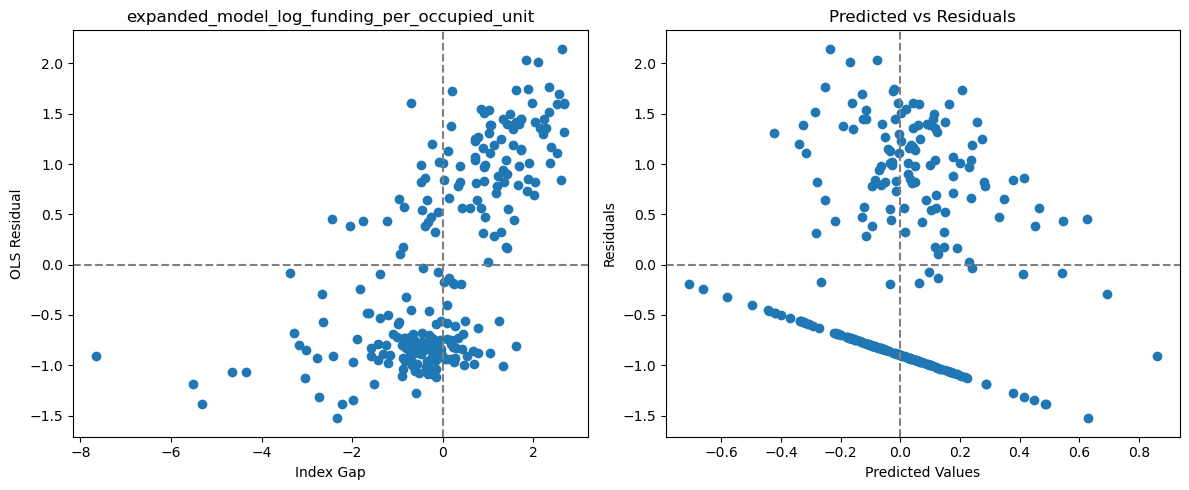

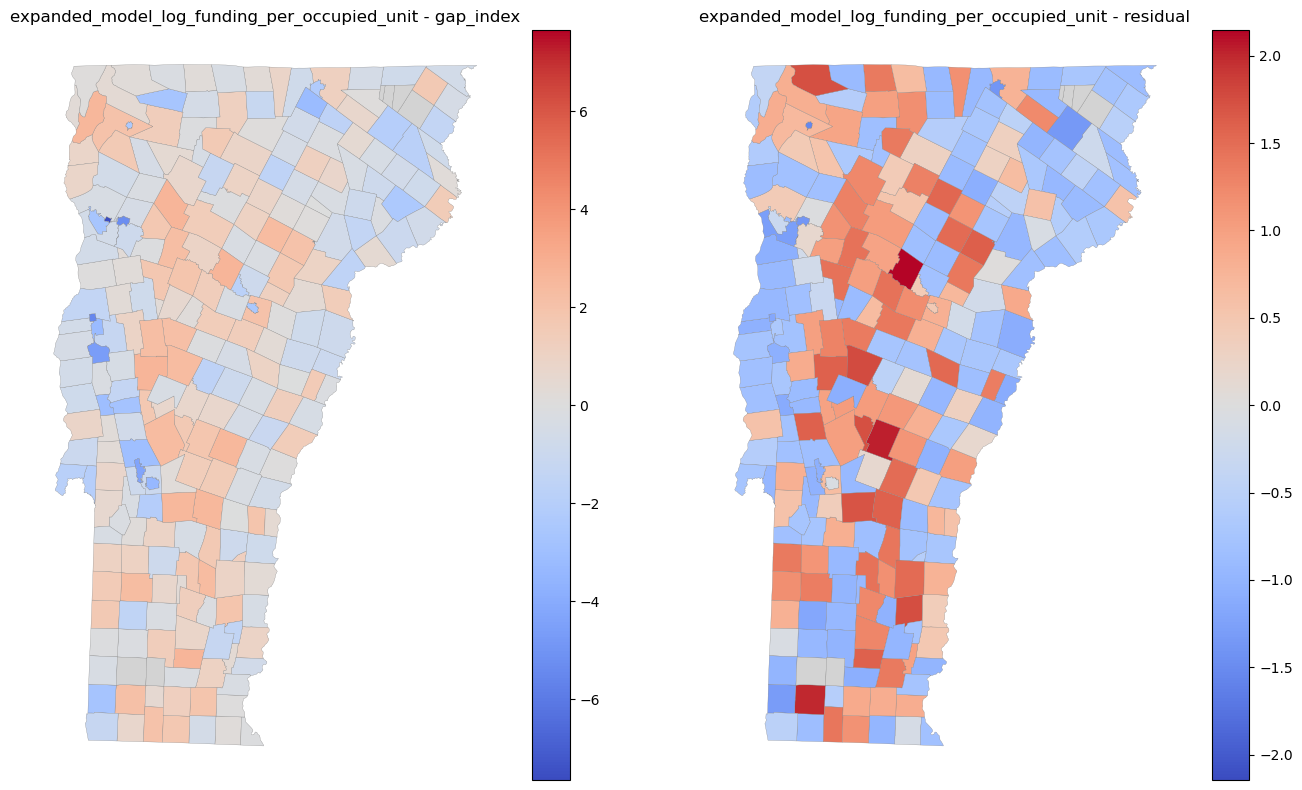

,town_name,gap_index,residual,rank_diff,abs_rank_diff
201,Stratton town,1.324494,-1.009535,178.0,178.0
25,Brandon town,-0.699132,1.602935,-177.0,177.0
12,Barre city,-2.451903,0.456411,-141.0,141.0
153,Peru town,0.684431,-0.992812,139.0,139.0
6,Averill town,1.621780,-0.804437,136.0,136.0
238,Westmore town,0.475844,-0.993223,135.0,135.0
174,Rutland city,-3.367713,-0.082883,-132.0,132.0
49,Clarendon town,-2.050097,0.382834,-131.0,131.0
66,Elmore town,1.034428,-0.881928,130.0,130.0
132,Montpelier city,-1.769534,0.433715,-129.0,129.0



=== RUNNING: nfhl_model_log_funding_per_occupied_unit ===


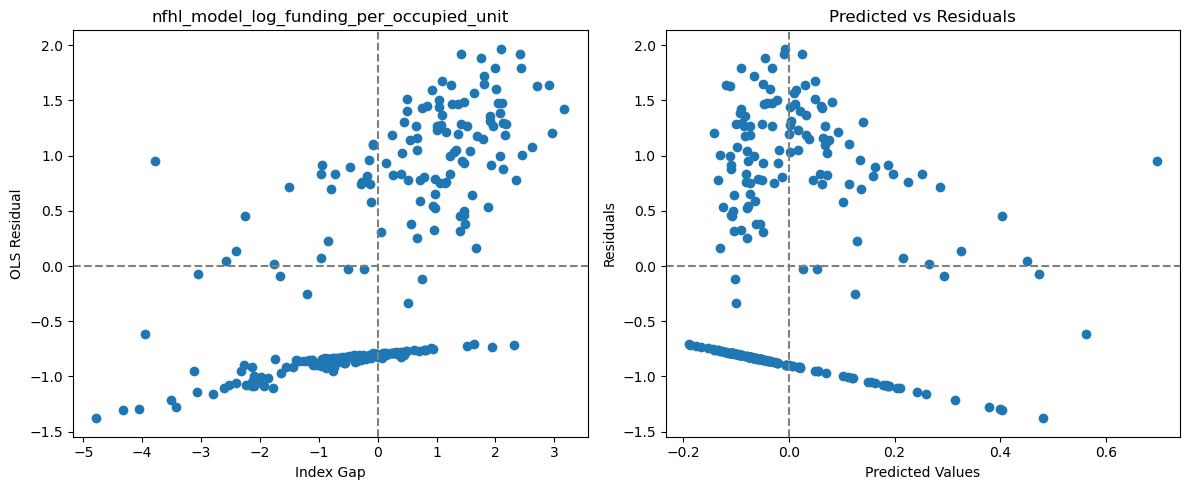

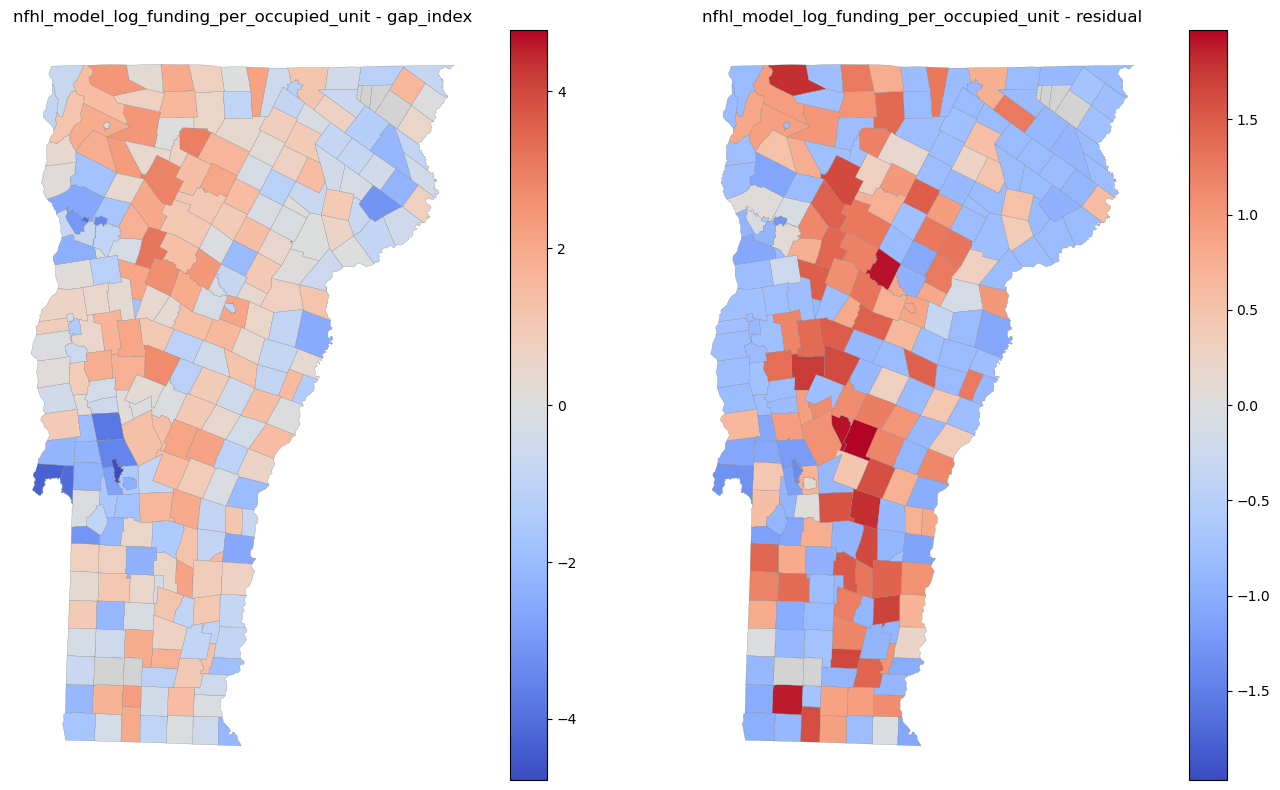

,town_name,gap_index,residual,rank_diff,abs_rank_diff
25,Brandon town,-3.787639,0.949886,-182.0,182.0
42,Castleton town,-2.247319,0.449066,-132.0,132.0
12,Barre city,-0.969545,0.831525,-128.0,128.0
243,Whitingham town,-0.938181,0.919374,-128.0,128.0
50,Colchester town,-2.584401,0.048057,-127.0,127.0
250,Winooski city,-3.958367,-0.615758,-127.0,127.0
37,Burlington city,-3.059985,-0.071795,-126.0,126.0
174,Rutland city,-2.401543,0.132861,-126.0,126.0
175,Rutland town,-1.510496,0.711704,-126.0,126.0
179,Searsburg town,2.308485,-0.711270,112.0,112.0



=== RUNNING: claims_only_log_funding_per_occupied_unit ===


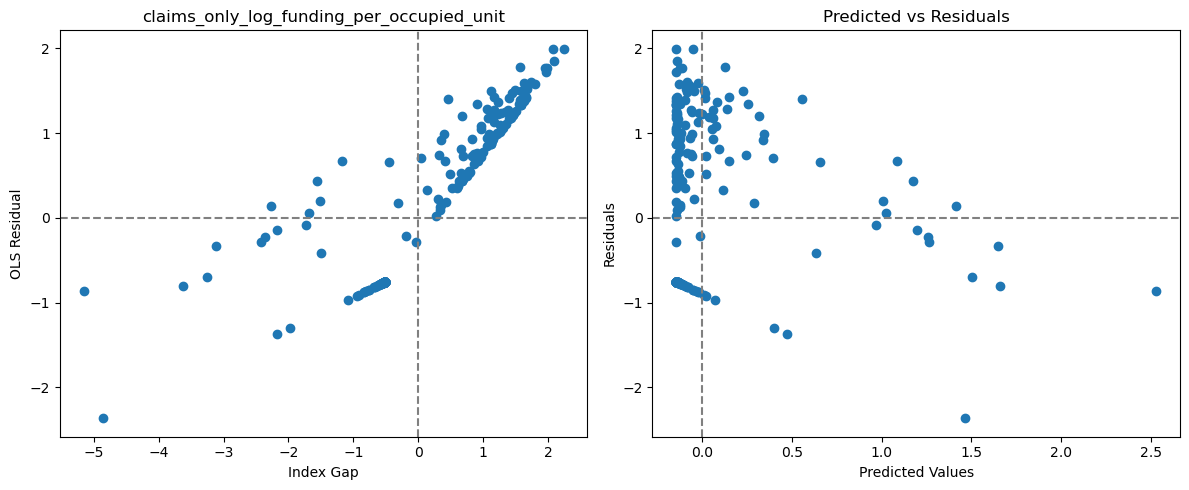

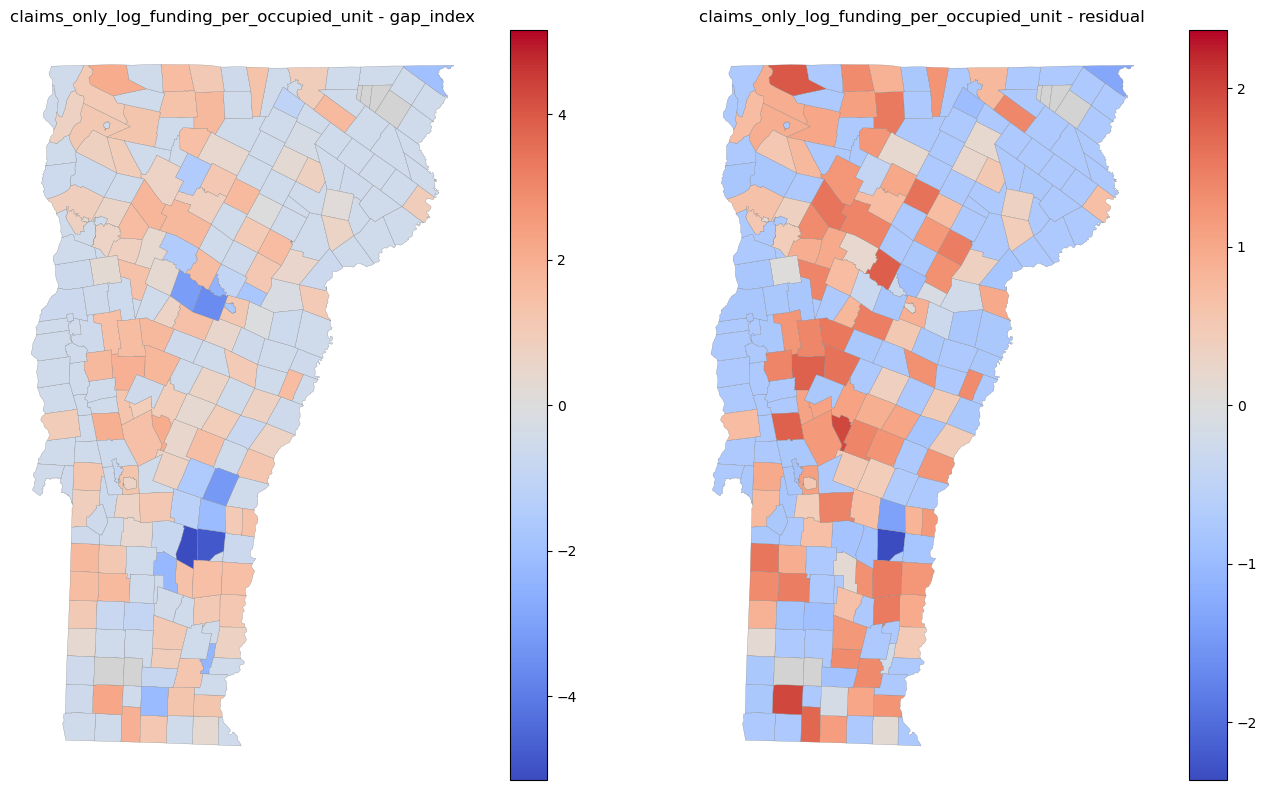

,town_name,gap_index,residual,rank_diff,abs_rank_diff
157,Plymouth town,-1.172174,0.674060,-156.0,156.0
27,Bridgewater town,-1.562104,0.433617,-145.0,145.0
239,Weston town,-2.261501,0.143398,-138.0,138.0
226,Waterbury town,-1.518743,0.192873,-135.0,135.0
32,Brookline town,-2.359277,-0.224852,-131.0,131.0
132,Montpelier city,-2.429616,-0.284833,-131.0,131.0
246,Wilmington town,-2.174281,-0.141013,-131.0,131.0
12,Barre city,-1.676038,0.060507,-130.0,130.0
133,Moretown town,-3.122581,-0.326714,-130.0,130.0
156,Plainfield town,-1.725960,-0.079211,-129.0,129.0



=== RUNNING: combined_log_funding_per_occupied_unit ===


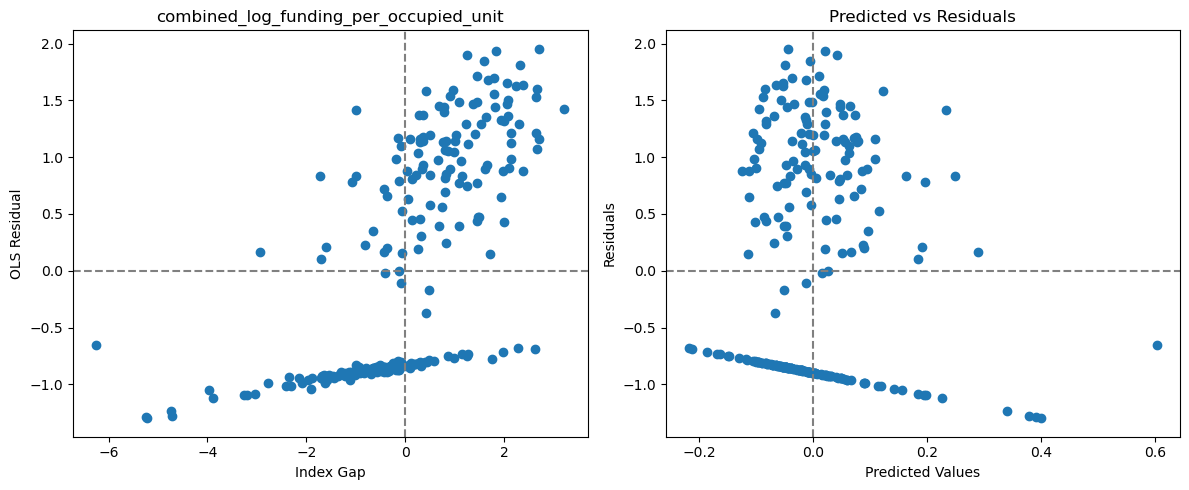

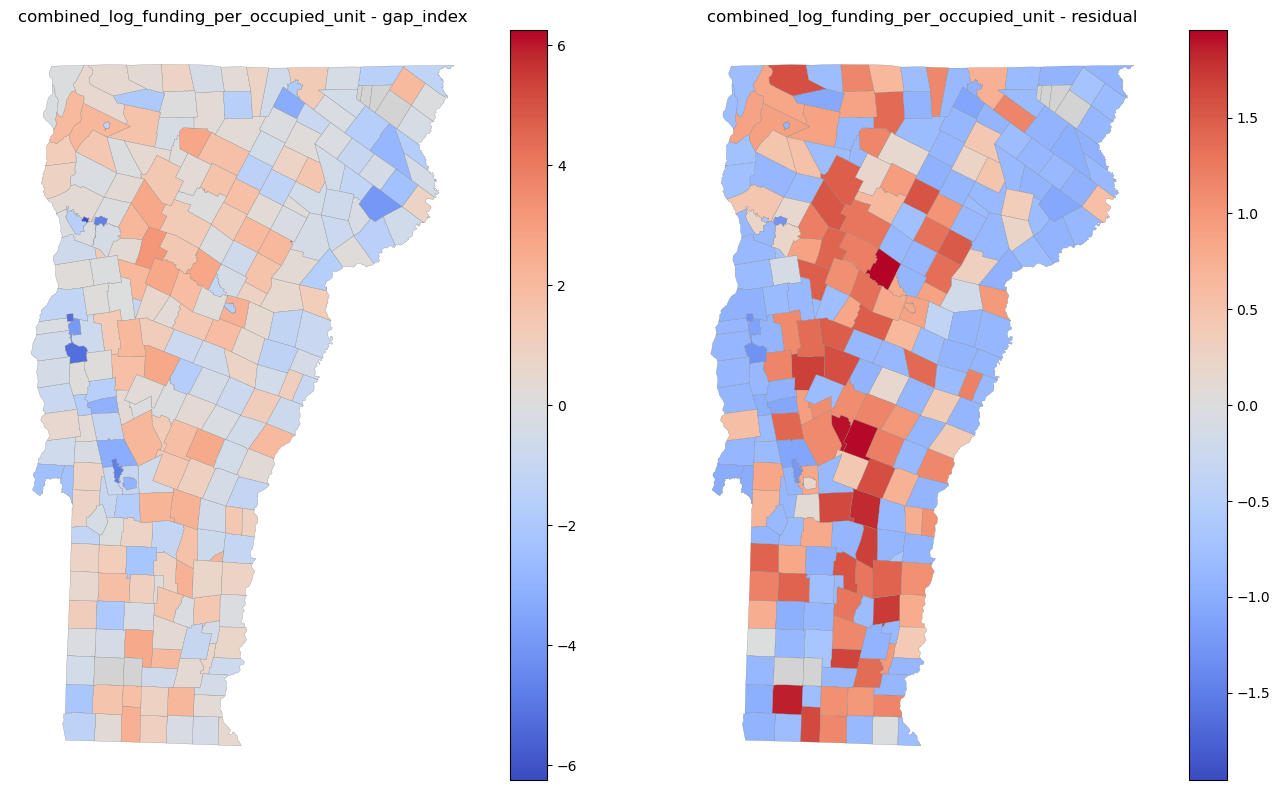

,town_name,gap_index,residual,rank_diff,abs_rank_diff
25,Brandon town,-0.996128,1.413033,-174.0,174.0
12,Barre city,-1.720465,0.833756,-152.0,152.0
174,Rutland city,-2.938264,0.169503,-130.0,130.0
250,Winooski city,-6.244820,-0.655612,-130.0,130.0
175,Rutland town,-1.002084,0.834457,-125.0,125.0
132,Montpelier city,-1.071575,0.781558,-123.0,123.0
37,Burlington city,-1.606232,0.210005,-116.0,116.0
49,Clarendon town,-1.702698,0.102214,-115.0,115.0
201,Stratton town,2.608907,-0.685917,114.0,114.0
9,Baltimore town,2.268064,-0.680980,108.0,108.0



=== SUMMARY ===


,r2,adj_r2,n_vars,n_obs,gap_resid_corr,gap_resid_spearman_corr,coef_signs,coef_directions,model
5,0.144063,0.140611,1,250,0.830529,0.902849,"{'const': 1.0679391398982219e-16, 'claims_paid...","{'const': 'pos', 'claims_paid_per_capita': 'pos'}",claims_only_log_funding_per_capita
12,0.137441,0.133963,1,250,0.827868,0.896980,"{'const': -2.2345406774926246e-16, 'claims_pai...","{'const': 'neg', 'claims_paid_per_capita': 'pos'}",claims_only_log_funding_per_occupied_unit
10,0.049374,0.025902,6,250,0.646179,0.658350,"{'const': -2.222614453595284e-17, 'pct_river_c...","{'const': 'neg', 'pct_river_corridor': 'pos', ...",expanded_model_log_funding_per_occupied_unit
3,0.047952,0.024445,6,250,0.645361,0.654326,"{'const': 2.710505431213761e-18, 'pct_river_co...","{'const': 'pos', 'pct_river_corridor': 'pos', ...",expanded_model_log_funding_per_capita
9,0.019121,0.003106,4,250,0.653865,0.787304,"{'const': -2.222614453595284e-17, 'pct_river_c...","{'const': 'neg', 'pct_river_corridor': 'pos', ...",core_model_log_funding_per_occupied_unit
11,0.019013,0.007050,3,250,0.669679,0.800377,"{'const': -2.222614453595284e-17, 'pct_high_ri...","{'const': 'neg', 'pct_high_risk_NFHL': 'pos', ...",nfhl_model_log_funding_per_occupied_unit
4,0.018498,0.006529,3,250,0.670379,0.798548,"{'const': 2.710505431213761e-18, 'pct_high_ris...","{'const': 'pos', 'pct_high_risk_NFHL': 'pos', ...",nfhl_model_log_funding_per_capita
2,0.018217,0.002188,4,250,0.653617,0.786322,"{'const': 2.710505431213761e-18, 'pct_river_co...","{'const': 'pos', 'pct_river_corridor': 'pos', ...",core_model_log_funding_per_capita
8,0.015318,0.003310,3,250,0.881137,0.908505,"{'const': -2.222614453595284e-17, 'pct_below_p...","{'const': 'neg', 'pct_below_poverty': 'pos', '...",baseline_vulnerability_log_funding_per_occupie...
1,0.014376,0.002356,3,250,0.882920,0.914141,"{'const': 2.710505431213761e-18, 'pct_below_po...","{'const': 'pos', 'pct_below_poverty': 'pos', '...",baseline_vulnerability_log_funding_per_capita


In [9]:
# results, summary = run_model_suite(df, gdf, model_specs)

expanded_specs = {}
for funding_var in ["log_funding_per_capita", "log_funding_per_occupied_unit"]:
    for name, spec in model_specs.items():
        new_name = f"{name}_{funding_var}"
        expanded_specs[new_name] = {**spec, "funding_var": funding_var}

results, summary = run_model_suite(df, gdf, expanded_specs)

In [10]:
# display head and tails of gap index for core model
# get_extremes(results["core_model"]["df"], "gap_index")

# get_extremes(results["core_model_log_funding_per_capita"]["df"], "gap_index")

# get_mismatch(results["core_model_log_funding_per_capita"]["df"], n=20)

In [11]:
for i, row in summary.iterrows():
    print(f"Model: {row['model']}")
    pprint.pprint(row["coef_directions"])
    print()

Model: claims_only_log_funding_per_capita
{'claims_paid_per_capita': 'pos', 'const': 'pos'}

Model: claims_only_log_funding_per_occupied_unit
{'claims_paid_per_capita': 'pos', 'const': 'neg'}

Model: expanded_model_log_funding_per_occupied_unit
{'const': 'neg',
 'pct_below_poverty': 'pos',
 'pct_mobile_home': 'neg',
 'pct_no_vehicle': 'pos',
 'pct_renter_occupied': 'pos',
 'pct_river_corridor': 'pos',
 'percent_elderly': 'pos'}

Model: expanded_model_log_funding_per_capita
{'const': 'pos',
 'pct_below_poverty': 'pos',
 'pct_mobile_home': 'neg',
 'pct_no_vehicle': 'pos',
 'pct_renter_occupied': 'pos',
 'pct_river_corridor': 'pos',
 'percent_elderly': 'pos'}

Model: core_model_log_funding_per_occupied_unit
{'const': 'neg',
 'pct_below_poverty': 'neg',
 'pct_no_vehicle': 'pos',
 'pct_river_corridor': 'pos',
 'percent_elderly': 'pos'}

Model: nfhl_model_log_funding_per_occupied_unit
{'const': 'neg',
 'pct_below_poverty': 'pos',
 'pct_high_risk_NFHL': 'pos',
 'percent_elderly': 'pos'}

Mode

In [12]:
# for i, row in summary.iterrows():
#     print(f"Model: {row['model']}")
#     pprint.pprint(row["coef_signs"])
#     print()